# Wearable — plot BMI160 motion run

Loads the **latest** `data/motion_*.csv` (captured by the `motion_csv` monitor filter while running the `bmi160_motion_log` sketch).

Three views:
1. **Acceleration** per axis over time (reliable raw signal)
2. **Angular rate** (gyro) per axis over time (reliable raw signal)
3. **Estimated 3D trajectory** by double-integrating acceleration — **illustrative only**. IMU dead-reckoning drifts quadratically, so this shows the *shape* of motion, not real coordinates.

Open from the repo; the first cell fixes the path whether the kernel starts at the repo root or in `notebooks/`.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

data = ROOT / "data"
runs = sorted(data.glob("motion_*.csv"), key=lambda p: p.stat().st_mtime)
CSV = runs[-1]

df = pd.read_csv(CSV)
print(f"{len(df)} samples from {CSV.name}  (≈{1/df['t_s'].diff().median():.0f} Hz)")
df.head()

1795 samples from motion_20260713_220053.csv  (≈50 Hz)


,t_s,ax_g,ay_g,az_g,gx_dps,gy_dps,gz_dps
0,0.000,-0.0142,-0.0974,1.0010,-1.04,-0.49,0.30
1,0.019,-0.0171,-0.0988,1.0156,-0.24,-0.43,0.30
2,0.039,-0.0172,-0.1063,1.0088,-0.73,-0.49,0.43
3,0.059,-0.0189,-0.1036,1.0080,-0.55,-0.30,0.37
4,0.079,-0.0200,-0.0969,1.0107,-0.55,-0.49,0.37


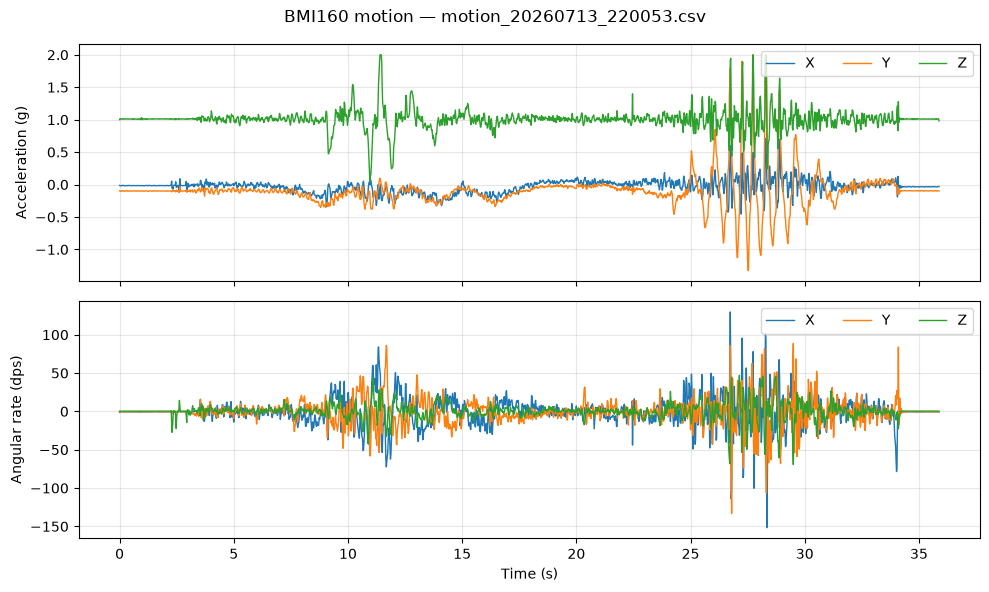

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
fig.suptitle(f"BMI160 motion — {CSV.name}")

for col, c, lbl in [("ax_g", "C0", "X"), ("ay_g", "C1", "Y"), ("az_g", "C2", "Z")]:
    ax1.plot(df["t_s"], df[col], color=c, linewidth=1.0, label=lbl)
ax1.set_ylabel("Acceleration (g)")
ax1.legend(loc="upper right", ncol=3)
ax1.grid(True, alpha=0.3)

for col, c, lbl in [("gx_dps", "C0", "X"), ("gy_dps", "C1", "Y"), ("gz_dps", "C2", "Z")]:
    ax2.plot(df["t_s"], df[col], color=c, linewidth=1.0, label=lbl)
ax2.set_ylabel("Angular rate (dps)")
ax2.set_xlabel("Time (s)")
ax2.legend(loc="upper right", ncol=3)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()  # inline only

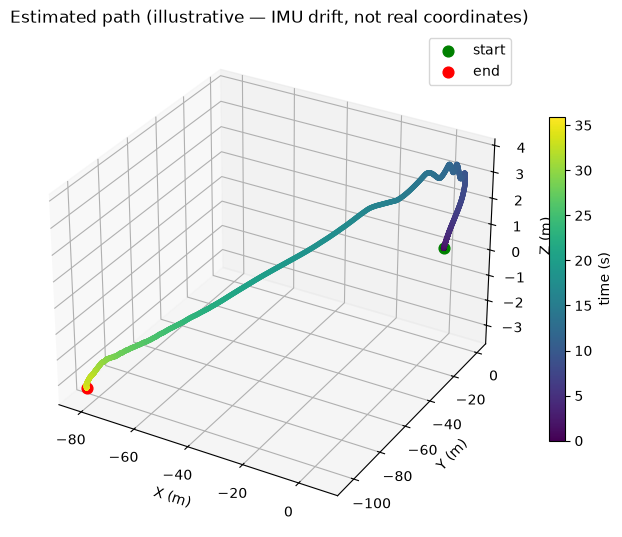

In [7]:
# Estimated 3D trajectory — ILLUSTRATIVE ONLY (dead-reckoning drift).
# Gravity removed by subtracting each axis mean; velocity is de-trended per axis
# (a crude drift correction) before integrating to position.
G = 9.81
t = df["t_s"].to_numpy()
dt = np.diff(t, prepend=t[0])
dt[dt <= 0] = np.median(dt[dt > 0])  # guard against duplicate timestamps

acc = df[["ax_g", "ay_g", "az_g"]].to_numpy() * G      # -> m/s^2
acc = acc - acc.mean(axis=0)                            # remove gravity + static bias

vel = np.cumsum(acc * dt[:, None], axis=0)
vel = vel - np.linspace(0, 1, len(vel))[:, None] * vel[-1]  # de-trend drift to end near 0

pos = np.cumsum(vel * dt[:, None], axis=0)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=t, cmap="viridis", s=8)
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], color="gray", linewidth=0.6, alpha=0.6)
ax.scatter(*pos[0], color="green", s=60, label="start")
ax.scatter(*pos[-1], color="red", s=60, label="end")
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z (m)")
ax.set_title("Estimated path (illustrative — IMU drift, not real coordinates)")
fig.colorbar(sc, ax=ax, shrink=0.6, label="time (s)")
ax.legend()
plt.show()